# Dungeons & Dragons - Análise de Personagens Únicos

Exploração do dataset `dnd_chars_unique.csv` (fichas de personagens criadas por jogadores reais), buscando padrões de criação, build de personagem e qualidade dos dados.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
caminho = '/content/drive/MyDrive/Dados/dnd_chars_unique.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Configurando o estilo dos gráficos do Seaborn
sns.set_theme(style="whitegrid")

# Carregar os dados
dnd = pd.read_csv(caminho, sep=';')

In [ ]:
dnd.head()

,ip,finger,hash,name,race,background,date,class,justClass,subclass,...,choices,country,countryCode,processedAlignment,good,lawful,processedRace,processedSpells,processedWeapons,alias
0,NaN,NaN,cae5e618234ee137e3c63d733786562d,076d33f5,Kenku,Guild Member - Spycraft,2022-08-21T21:36:28Z,Ranger 20,Ranger,Beast Master,...,expertise/Perception|fighting style/Archery|op...,Canada,CA,NaN,NaN,NaN,Kenku,Fog Cloud*1|Absorb Elements*1|Speak with Anima...,Dagger|Dagger|Longbow,compassionate_mclaren
1,NaN,168df55,e60ba474b72646161a0eda0111f43a4e,1747c66f,Fallen Aasimar,Far Traveler,2022-08-21T21:13:26Z,Druid 20,Druid,Circle of the Moon,...,NaN,Canada,CA,CN,NaN,NaN,Aasimar,Infestation*0|Light*0|Poison Spray*0|Primal Sa...,Quarterstaff|Dagger,crazy_gould
2,NaN,2883dc0,5307fd9971cdc6c718382ab2c28eee79,e38541dc,Leonin,Soldier,2022-08-17T11:20:11Z,Fighter 20,Fighter,Rune Knight,...,fighting style/Great Weapon Fighting,Canada,CA,LG,NaN,NaN,Leonin,NaN,|,brave_rhodes
3,fe2ccee,d00f08e,6eacdd847b0a192ed5274d215e6a2bed,8f563448,Warforged,Barbarian Tribe Member,2022-08-13T20:04:58Z,Druid 20,Druid,Circle of the Moon,...,NaN,United States,US,NaN,NaN,NaN,Warforged,NaN,Scimitar,flamboyant_chandrasekhar
4,6fdd75d,461d953,bcb6122fe0174ce0dd17c9a9afeae303,be717d80,Tiefling,Acolyte,2022-06-28T18:42:34Z,Cleric 20,Cleric,Tempest Domain,...,NaN,NaN,NaN,NaN,NaN,NaN,Tiefling,Sacred Flame*0|Spare the Dying*0|Fog Cloud*1|T...,Mace,dreamy_banzai


## 1. Atributos básicos por classe

A primeira pergunta é a mais óbvia: os jogadores estão seguindo a "lógica" do sistema na hora de distribuir atributos? Bárbaro com Força alta, Ladino com Destreza alta, Clérigo com Sabedoria alta, etc. Vou comparar a média dos 6 atributos para as classes mais populares do dataset.

In [ ]:
# As 5 classes mais populares
top_classes = dnd['justClass'].value_counts().head(5).index
df_filtered = dnd[dnd['justClass'].isin(top_classes)]

In [ ]:
print(top_classes)

Index(['Fighter', 'Rogue', 'Cleric', 'Barbarian', 'Paladin'], dtype='object', name='justClass')


In [ ]:
atributos = ['Str', 'Dex', 'Con', 'Int', 'Wis', 'Cha']
df_grouped = df_filtered.groupby('justClass')[atributos].mean().reset_index()

In [ ]:
# Formato longo, melhor pro Seaborn
df_melted = df_grouped.melt(id_vars='justClass', var_name='Atributo', value_name='Valor Médio')

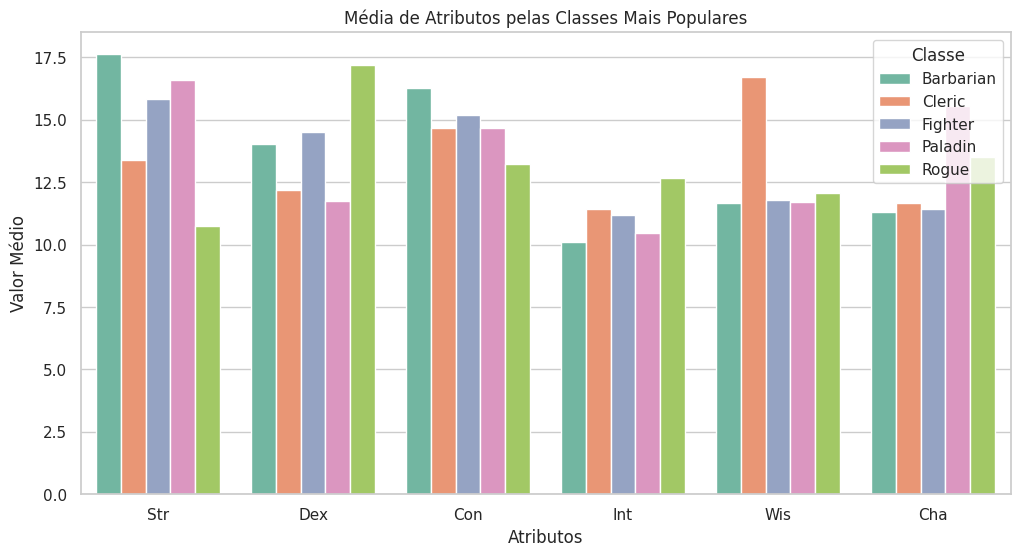

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Atributo', y='Valor Médio', hue='justClass', palette='Set2')
plt.title('Média de Atributos pelas Classes Mais Populares')
plt.xlabel('Atributos')
plt.ylabel('Valor Médio')
plt.legend(title='Classe')
plt.savefig('atributos_por_classe.png', bbox_inches='tight')

## 2. Combinações de raça e classe

Quais combinações de raça e classe aparecem mais? Dá pra ver se existe uma preferência forte por certos combos (Elfo Mago, Anão Guerreiro) ou se a escolha é bem distribuída.

In [ ]:
# Top 8 raças e top 8 classes, pra não poluir o gráfico
top_races = dnd['processedRace'].value_counts().head(8).index
top_classes_8 = dnd['justClass'].value_counts().head(8).index
print(top_races, top_classes_8, sep="\n")

Index(['Human', 'Elf', 'Half-Elf', 'Dwarf', 'Tiefling', 'Halfling',
       'Dragonborn', 'Gnome'],
      dtype='object', name='processedRace')
Index(['Fighter', 'Rogue', 'Cleric', 'Barbarian', 'Paladin', 'Wizard',
       'Ranger', 'Bard'],
      dtype='object', name='justClass')


In [ ]:
df_combo = dnd[dnd['processedRace'].isin(top_races) & dnd['justClass'].isin(top_classes_8)]

In [ ]:
cross_tab = pd.crosstab(df_combo['processedRace'], df_combo['justClass'])

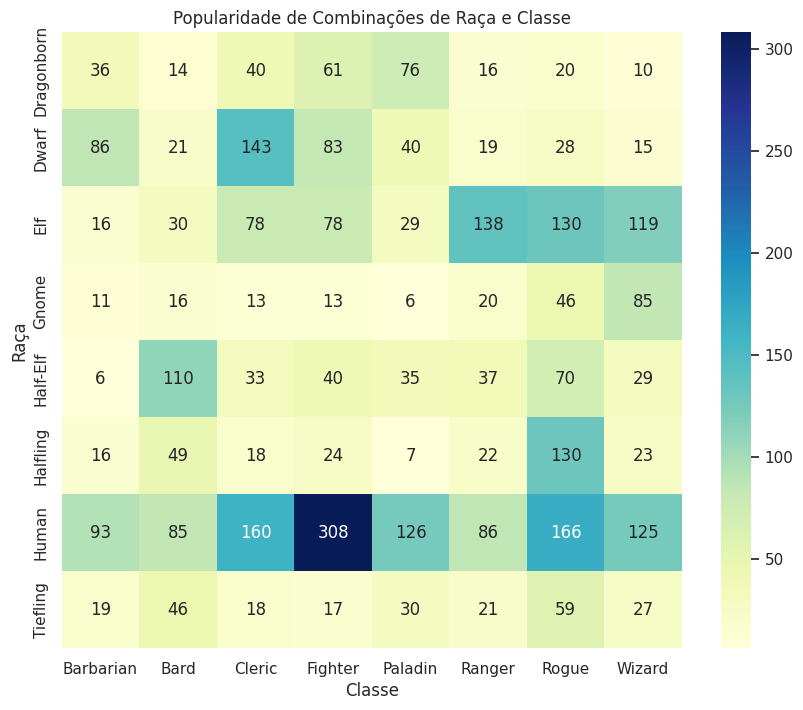

In [ ]:
# Plotando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title('Popularidade de Combinações de Raça e Classe')
plt.xlabel('Classe')
plt.ylabel('Raça')
plt.savefig('heatmap_raca_classe.png', bbox_inches='tight')

## 3. HP, AC e nível

Como HP e AC evoluem junto com o nível do personagem? A ideia é checar a correlação entre essas variáveis e ver se a Classe de Armadura cresce no mesmo ritmo que o HP ou se estabiliza em algum ponto.

In [ ]:
matriz_corr = dnd[['level', 'HP', 'AC', 'Con']].corr()
print("Matriz de Correlação:")
print(matriz_corr)

Matriz de Correlação:
          level        HP        AC       Con
level  1.000000  0.653062  0.208433  0.260322
HP     0.653062  1.000000  0.667950  0.393731
AC     0.208433  0.667950  1.000000  0.298074
Con    0.260322  0.393731  0.298074  1.000000


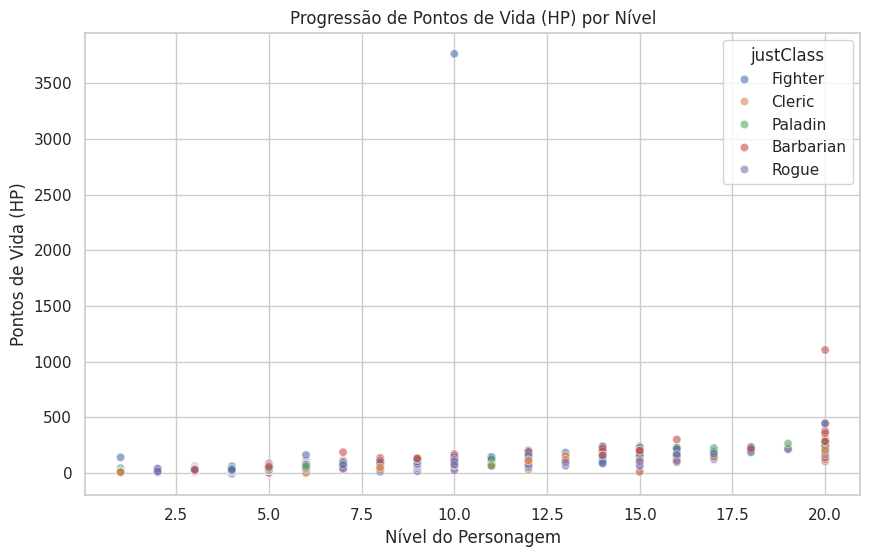

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='level', y='HP', hue='justClass', alpha=0.6)
plt.title('Progressão de Pontos de Vida (HP) por Nível')
plt.xlabel('Nível do Personagem')
plt.ylabel('Pontos de Vida (HP)')
plt.savefig('progressao_hp_nivel.png', bbox_inches='tight')

## 4. Multiclasse

No D&D dá pra misturar classes (ex: Sorcerer 13 | Cleric 1), e isso aparece no dataset como um '|' dentro da coluna `justClass`. Criei uma coluna booleana pra marcar quem é multiclasse e comparar o nível desses personagens com o de classe única.

In [ ]:
dnd['is_multiclass'] = dnd['justClass'].str.contains(r'\|')

In [ ]:
# Verificar proporção
print(dnd['is_multiclass'].value_counts(normalize=True))

is_multiclass
False    0.940725
True     0.059275
Name: proportion, dtype: float64


/tmp/ipykernel_2779/2878123698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dnd, x='is_multiclass', y='level', palette='Pastel1')


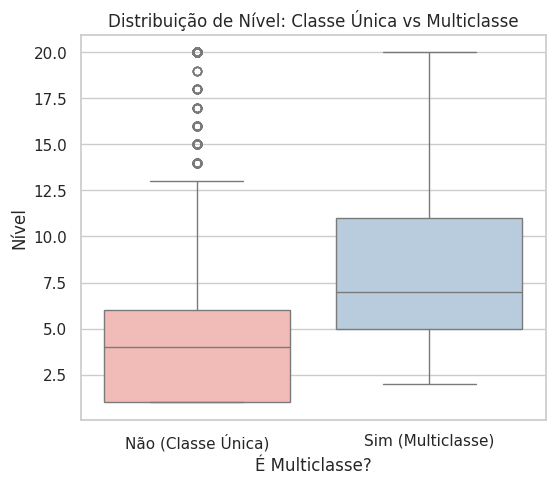

In [ ]:
# Comparar o nível médio de personagens de classe única vs multiclasse
plt.figure(figsize=(6, 5))
sns.boxplot(data=dnd, x='is_multiclass', y='level', palette='Pastel1')
plt.title('Distribuição de Nível: Classe Única vs Multiclasse')
plt.xlabel('É Multiclasse?')
plt.ylabel('Nível')
plt.xticks([0, 1], ['Não (Classe Única)', 'Sim (Multiclasse)'])
plt.savefig('distribuicao_multiclasse.png', bbox_inches='tight')

## 5. Distribuição geográfica e temporal

De onde vêm os registros e como a criação de fichas se distribui ao longo dos anos.

In [ ]:
# Convertendo a data
dnd['date_parsed'] = pd.to_datetime(dnd['date'], errors='coerce')
dnd['year'] = dnd['date_parsed'].dt.year

/tmp/ipykernel_2779/2202439319.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dnd.dropna(subset=['year']), x='year', palette='viridis')


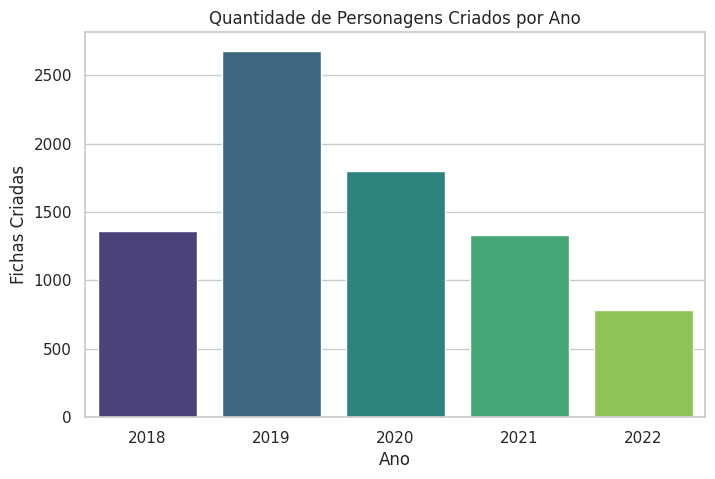

In [ ]:
# Gráfico de barras por Ano de criação
plt.figure(figsize=(8, 5))
sns.countplot(data=dnd.dropna(subset=['year']), x='year', palette='viridis')
plt.title('Quantidade de Personagens Criados por Ano')
plt.xlabel('Ano')
plt.ylabel('Fichas Criadas')
plt.savefig('criacao_por_ano.png', bbox_inches='tight')

In [ ]:
# Países que mais utilizam a ferramenta
print("\nTop 5 Países com mais registros:")
print(dnd['country'].value_counts().head(5))


Top 5 Países com mais registros:
country
United States     2753
Canada            1727
United Kingdom     265
Brazil             122
Australia          121
Name: count, dtype: int64


## 6. Magias mais escolhidas

Quais truques (nível 0) e magias de 1º círculo aparecem com mais frequência entre os personagens conjuradores.

In [ ]:
from collections import Counter

In [ ]:
# Filtrar linhas válidas na coluna de magias
df_spells = dnd['processedSpells'].dropna()

In [ ]:
# Extrair todas as magias individualmente
todas_as_magias = []
for lista_magias in df_spells:
    # Separar por '|'
    magias = lista_magias.split('|')
    todas_as_magias.extend(magias)

In [ ]:
# Remove espaços e placeholders tipo '*'
todas_as_magias = [m.strip() for m in todas_as_magias if m.strip() and m != '*']

In [ ]:
# Contar as magias mais comuns
contagem_magias = Counter(todas_as_magias)
print("Top 10 Magias/Truques mais escolhidos pelos jogadores:")
for magia, qtd in contagem_magias.most_common(10):
    print(f"- {magia}: {qtd} vezes")

Top 10 Magias/Truques mais escolhidos pelos jogadores:
- Cure Wounds*1: 871 vezes
- Mage Hand*0: 533 vezes
- Healing Word*1: 445 vezes
- Light*0: 442 vezes
- Detect Magic*1: 441 vezes
- Shield*1: 429 vezes
- Fire Bolt*0: 419 vezes
- Minor Illusion*0: 419 vezes
- Bless*1: 391 vezes
- Thunderwave*1: 365 vezes


## 7. Min-maxing de atributos

Quais classes apostam tudo em um atributo só e quais distribuem os pontos de forma mais equilibrada?

Pra medir isso, calculei o desvio padrão dos 6 atributos de cada personagem. Desvio alto = build concentrada em poucos atributos (ex: Bárbaro com Força 20 e Inteligência 8); desvio baixo = atributos mais parecidos entre si.

In [ ]:
# Lista de atributos
atributos = ['Str', 'Dex', 'Con', 'Int', 'Wis', 'Cha']

In [ ]:
dnd['std_atributos'] = dnd[atributos].std(axis=1)

In [ ]:
# Descobrir quais classes têm maior desvio padrão médio
top_classes = dnd['justClass'].value_counts().head(6).index
df_minmax = dnd[dnd['justClass'].isin(top_classes)]

/tmp/ipykernel_2779/31238332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_minmax, x='justClass', y='std_atributos', palette='Set3')


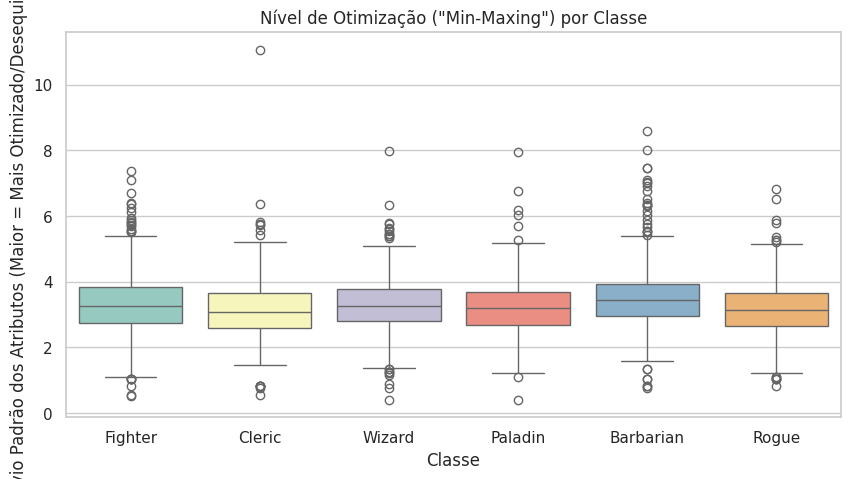

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_minmax, x='justClass', y='std_atributos', palette='Set3')
plt.title('Nível de Otimização ("Min-Maxing") por Classe')
plt.xlabel('Classe')
plt.ylabel('Desvio Padrão dos Atributos (Maior = Mais Otimizado/Desequilibrado)')
plt.savefig('min_maxing_classes.png', bbox_inches='tight')

## 8. Equipamento e arsenal

Criando flags a partir das armas de cada personagem (arco, escudo, arma pesada) pra cruzar com a classe.

In [ ]:
dnd['usa_arco'] = dnd['processedWeapons'].fillna('').str.contains('Bow|Longbow|Shortbow', case=False)
dnd['usa_escudo'] = dnd['processedWeapons'].fillna('').str.contains('Shield', case=False)
dnd['usa_espada_pesada'] = dnd['processedWeapons'].fillna('').str.contains('Greatsword|Halberd|Greataxe', case=False)

In [ ]:
# Cruzar estilo de arma com a classe
classes_combate = ['Fighter', 'Paladin', 'Ranger', 'Barbarian']
df_armas = dnd[dnd['justClass'].isin(classes_combate)]

In [ ]:
# Ver a proporção de uso de arco por classe de combate
proporcao_arco = df_armas.groupby('justClass')['usa_arco'].mean().reset_index()

/tmp/ipykernel_2779/2551241269.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proporcao_arco, x='justClass', y='usa_arco', palette='Blues_r')


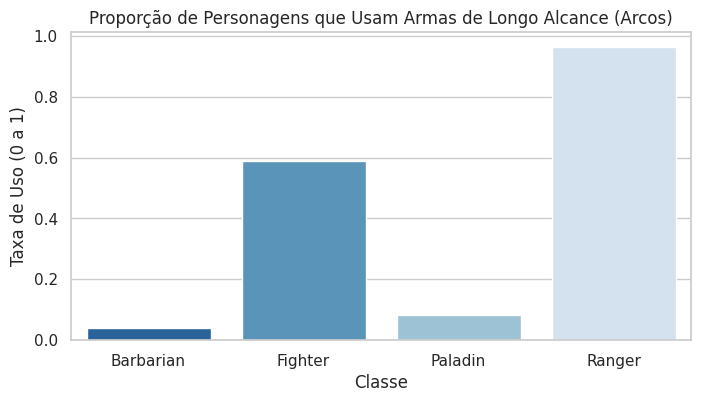

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=proporcao_arco, x='justClass', y='usa_arco', palette='Blues_r')
plt.title('Proporção de Personagens que Usam Armas de Longo Alcance (Arcos)')
plt.xlabel('Classe')
plt.ylabel('Taxa de Uso (0 a 1)')
plt.savefig('uso_arcos_classe.png', bbox_inches='tight')

## 9. Clustering com K-Means

Olhando só pros números da ficha (atributos, HP, AC), o algoritmo separa os personagens em grupos que fazem sentido (ex: tanque, conjurador, ágil)? Usei 3 clusters como ponto de partida pra comparar com as classes reais.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
atributos = ['Str', 'Dex', 'Con', 'Int', 'Wis', 'Cha', 'HP', 'AC']
X = dnd[atributos]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dnd['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Cruzando os clusters com as classes reais, pra ver se bateu
print("Distribuição das Classes Reais dentro dos Clusters criados pelo K-Means:")
print(pd.crosstab(dnd['justClass'], dnd['cluster']).loc[['Fighter', 'Wizard', 'Rogue', 'Barbarian']])

Distribuição das Classes Reais dentro dos Clusters criados pelo K-Means:
cluster      0    1  2
justClass             
Fighter    253  726  1
Wizard     517   24  0
Rogue      840   54  0
Barbarian   31  608  0


## 10. Dados faltantes

/tmp/ipykernel_2779/2236551938.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.values, y=missing_data.index, palette='mako')


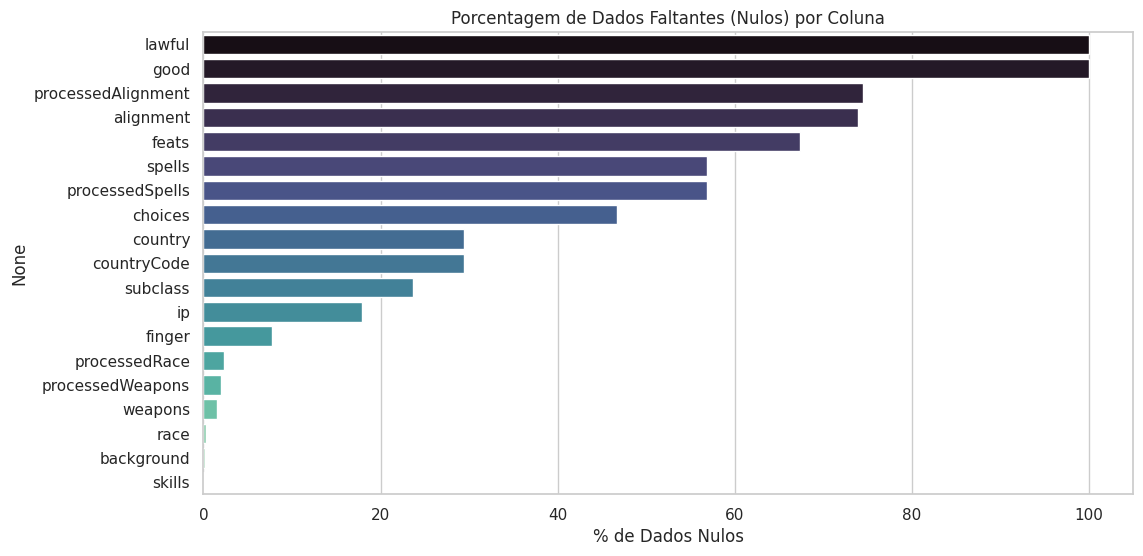

In [ ]:
plt.figure(figsize=(12, 6))
missing_data = dnd.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

sns.barplot(x=missing_data.values, y=missing_data.index, palette='mako')
plt.title('Porcentagem de Dados Faltantes (Nulos) por Coluna')
plt.xlabel('% de Dados Nulos')
plt.savefig('dados_faltantes.png', bbox_inches='tight')